In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange,tqdm
import numbers
import math

In [2]:
#Functions:
def Rect(x,tau):
  r=x*0
  r[abs(x)<0.5*tau]=1/tau
  return r

def Exp(x):
  r=x*0
  r=np.exp(-x)
  r[x<0]=0
  return r

def AdjustRefFrame(l):

  l2=np.copy(l)
  l2[:,1]=np.roll(l2[:,1],-int(l2[np.argmax(l2[:,1]),0]),0)

  return l2

def E(d,tau,i,lam):
  a=CA(d,tau,lam)
  b=a+d

  if isinstance(a, numbers.Number):
    if a<-d*tau/2:
      a=-d*tau/2
  else:
    a[a<-d*tau/2]=-d[a<-d*tau/2]*tau/2

  if i==0:
    return (tau*d/2-a+(np.exp(-lam*(tau*d))-np.exp(-lam*(a+tau*d/2)))/lam-2*np.sinh(lam*tau*d/2)/lam*(np.exp(-lam*(b))-np.exp(-lam*(tau*d/2))))/tau/d
  elif i>0:
    return -2*np.sinh(d*lam*tau/2)/d/lam/tau*(np.exp(-lam*(a+d*(1+i)))-np.exp(-lam*(a+d*i)))
  elif i<0:
    if a+d*(i+1)<=-d*tau/2:
      return 0
    elif a+d*i<=-d*tau/2:
      return 1/d/tau*((a+d*(i+1)+d*tau/2)+1/lam*(np.exp(-lam*(a+d*(1+i)+d*tau/2))-1))
    else:
      return 1/d/tau*(d+1/lam*(np.exp(-lam*(a+d*(1+i)+d*tau/2))-np.exp(-lam*(a+d*i+d*tau/2))))
  else:
    return np.nan

def E2(d,tau,i,lam):
  a=CA(d,tau,lam)
  b=a+d

  if isinstance(a, numbers.Number):
    if a<-d*tau/2:
      a=-d*tau/2
  else:
    a[a<-d*tau/2]=-d[a<-d*tau/2]*tau/2

  if i==0:
    return (tau*d/2-a+(np.exp(-lam*(tau*d))-np.exp(-lam*(a+tau*d/2)))/lam-2*np.sinh(lam*tau*d/2)/lam*(np.exp(-lam*(b))-np.exp(-lam*(tau*d/2))))/tau/d
  elif i>0:
    return -2*np.sinh(d*lam*tau/2)/d/lam/tau*(np.exp(-lam*(a+d*(1+i)))-np.exp(-lam*(a+d*i)))
  elif i<-1:
    return 0
  elif i==-1:
    return 1/d/tau*((a+d*tau/2)+1/lam*(np.exp(-lam*(a+d*tau/2))-1))


def s(x,lam,tau,d):
  y=x*0
  y[x>-tau*d/2]=1/tau*(1-np.exp(-lam*(x[x>-tau*d/2]+tau*d/2)))
  y[x>=tau*d/2]=1/tau*(2*np.exp(-lam*x[x>=tau*d/2])*np.sinh(lam*tau*d/2))
  return y

def CA(d,tau,lam):
  B=tau/(2*np.sinh(lam*tau*d/2))
  A=np.exp(lam*d*(tau/2-1))
  y=A/(A*tau+B)
  a=-np.log(1-y*tau)/lam-tau*d/2
  return a

def Si_MC(i,n,tau,eta,f):
  dt=1/n
  ti=i*dt
  x=np.linspace(ti+dt*(eta-tau/2),ti+dt*(eta+tau/2),1000)
  dx=x[1]-x[0]
  return i,np.sum(f(x)*dx/tau)

def GetLM(n,tau):

  s=100000
  lm=np.zeros(s)
  for lap in range(s):
    eta=(np.random.rand()-0.5)*3
    l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-2,11)])
    #l=AdjustRefFrame(l)
    lm[lap]=np.max(l[:,1])

  return np.nanmean(lm),np.nanvar(lm)

def GetLM_TM(n,tau):

  s=100000
  lm=np.zeros(s)
  T=np.array([E2(1/n,tau,i,1) for i in range(-2,21)])
  for lap in range(s):
    eta=(np.random.rand()-0.5)*3
    l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-2,21)])
    l=AdjustRefFrame(l)
    lm[lap]=np.sum(T*l[:,1])

  return np.nanmean(lm),np.nanvar(lm)

def GetLM_TM2(n,tau):
    return np.array([GetLM_TM(n0,tau) for n0 in tqdm(n)])

def GetLM3(n,tau1,tau2):

  s=100000
  lm=np.zeros(s)
  for lap in range(s):
    eta=(np.random.rand()-0.5)*3
    l=np.array([Si_MC(i,n,tau1,eta,Exp) for i in np.arange(-2,11)])
    eta=(np.random.rand()-0.5)*3
    l2=np.array([Si_MC(i,n,tau2,eta,Exp) for i in np.arange(-2,11)])
    #l=AdjustRefFrame(l)
    lm[lap]=np.max(l2[:,1])/np.max(l[:,1])

  return np.nanmean(lm),np.nanvar(lm)

def GetLM2(n,tau):
    return np.array([GetLM(n0,tau) for n0 in tqdm(n)])

def GetLM4(n,tau1,tau2):
    return np.array([GetLM3(n0,tau1,tau2) for n0 in tqdm(n)])

def V(d,tau,i,lam):
  a=CA(d,tau,lam)
  if isinstance(a, numbers.Number):
    if a<-d*tau/2:
      a=-d*tau/2
  else:
    a[a<-d*tau/2]=-d[a<-d*tau/2]*tau/2

  b=a+d

  if i==0:
    P1=tau*d/2-a+2/lam*(np.exp(-lam*tau*d)-np.exp(-lam*(a+tau*d/2)))-1/(2*lam)*(np.exp(-2*lam*tau*d)-np.exp(-2*lam*(a+tau*d/2)))
    P2=-2*np.sinh(lam*tau*d/2)**2/lam*(np.exp(-2*lam*b)-np.exp(-lam*tau*d))
    return (P1+P2)/tau**2/d-E2(d,tau,i,lam)**2
  elif i==-1:
    P1=1/(d*tau**2)*(a+tau*d/2+1/2/lam*(4*np.exp(-lam*(a+d*tau/2))-np.exp(-2*lam*(a+d*tau/2))-3))
    return P1-E2(d,tau,i,lam)**2
  elif i>0:
    P1=-2/(lam*d*tau**2)*np.sinh(lam*tau*d/2)**2*np.exp(-2*lam*(a+d*i))*(np.exp(-2*lam*d)-1)
    return P1-E2(d,tau,i,lam)**2
  else:
    return 0

def pS(d,tau,lam):
  a=CA(d,tau,lam)
  b=a+d
  yp=s(np.array([a,d*tau/2]),lam,tau,d)
  y=np.linspace(yp[0],yp[1],10000)

  P1=tau/(1-tau*y)/(np.log(1-yp[0]*tau)-np.log(1-yp[1]*tau))*(d*tau/2-a)/d
  P2=1/y/(np.log(yp[1])-np.log(yp[0]))*(b-d*tau/2)/d

  return y,P2+P1

def CV_LM(d,tau,sn):

  lm=[]
  for lap in trange(sn):
    eta=(np.random.rand()-0.5)*3
    l=np.array([Si_MC(i,1/d,tau,eta,Exp) for i in np.arange(-1,51)])
    l=AdjustRefFrame(l)
    lm.append(l[:,1])

  return np.array(lm)

def CV(i1i,i2i,d,tau,lam):

  if i1i==i2i:
    return V(d,tau,i1i,lam)
  else:
    a=CA(d,tau,lam)
    if i1i>i2i:
      i1=i2i
      i2=i1i
    else:
      i1=i1i
      i2=i2i

    if i1==-1:
      P1=-2/lam/d/tau**2*np.sinh(lam*tau*d/2)*(np.exp(-lam*((i2+1)*d+a))-np.exp(-lam*((i2+1)*d-d*tau/2))-0.5*np.exp(-lam*(2*a+(i2+1)*d+d*tau/2))+0.5*np.exp(-lam*((i2+1)*d-d*tau/2)))
      P2=E2(d,tau,i1,lam)*E2(d,tau,i2,lam)
      return P1-P2
    elif i1==0:
      P1=-2/lam/d/tau**2*np.sinh(lam*tau*d/2)*(np.exp(-lam*(i2*d+d*tau/2))-np.exp(-lam*(i2*d+a))-0.5*np.exp(-lam*(d*tau+i2*d+d*tau/2))+0.5*np.exp(-lam*(i2*d+d*tau/2+2*a)))
      P3=-2/lam/d/tau**2*np.sinh(lam*tau*d/2)**2*(np.exp(-lam*(2*a+d*(i2+2)))-np.exp(-lam*(d*tau+d*i2)))
      P2=E2(d,tau,i1,lam)*E2(d,tau,i2,lam)
      return P1-P2+P3
    elif i1>0:
      P1=-2/lam/d/tau**2*np.sinh(lam*tau*d/2)**2*(np.exp(-lam*(2*a+d*(i1+i2+2)))-np.exp(-lam*(2*a+d*(i1+i2))))
      P2=E2(d,tau,i1,lam)*E2(d,tau,i2,lam)
      return P1-P2

def EC(d,tau,lam):
    return np.sum(np.array([E2(d,tau,i,lam)**2 for i in range(-1,101)]),0)

def VC(d,tau,lam):
    V=d*0
    for i in range(-1,31):
      for j in range(-1,31):
        V=V+E2(d,tau,i,lam)*E2(d,tau,j,lam)*CV(i,j,d,tau,lam)
    return V

def CDF(x,p):
  cdf=x*0
  dx=x[1]-x[0]
  cdf[0]=p[0]*dx
  for i in range(1,len(x)):
    cdf[i]=cdf[i-1]+p[i]*dx
  return cdf

def PlotPercentile(tau,clr,lb):

  n2=np.linspace(1e-1,5,200)
  lam=1

  data=[]

  for lap in range(len(n2)):

    y,P=pS(1/n2[lap],tau,lam)

    xp=[0.05,0.25,0.50,0.75,0.95]
    data.append(np.interp(xp,CDF(y,P),y))

  data=np.array(data)

  plt.plot(n2,data[:,0],'-.',color=clr,label=lb+' - 5th')
  plt.plot(n2,data[:,1],'--',color=clr,label=lb+' - 25th')
  plt.plot(n2,data[:,2],'-',color=clr,label=lb+' - 50th')
  plt.plot(n2,data[:,3],'--',color=clr,label=lb+' - 75th')
  plt.plot(n2,data[:,4],'-.',color=clr,label=lb+' - 95th')

def pC(d,tau,lam):
  a=CA(d,tau,lam)
  x=np.linspace(a,a+d,20000)
  yp=x*0
  for i in range(-1,101):
    yp=yp+s(x+i*d,lam,tau,d)*E2(d,tau,i,lam)

  mx=max(yp)
  mn=min(yp)

  y=np.linspace(mn*0.9,mx*1.1,20000)
  dy=y[1]-y[0]

  ind1=np.argmax(yp)
  x1=yp[0:ind1+1]
  y1=x[0:ind1+1]-a

  P1=np.interp(y,x1,y1)
  P1=np.gradient(P1,dy)
  P1[y>max(x1)]=0
  P1[y<min(x1)]=0
  P1=P1/(np.sum(P1)*dy)
  P1=P1*(x[ind1]-a)/d

  x2=yp[ind1:]
  y2=x[ind1:]-a

  P2=np.interp(-y,-x2,y2)
  P2=-np.gradient(P2,dy)
  P2[y>max(x2)]=0
  P2[y<min(x2)]=0
  P2=P2/(np.sum(P2)*dy)
  P2=P2*(1-(x[ind1]-a)/d)

  P=P1+P2
  P=P[(y>mn)*(y<mx)]
  P=P[2:-1]
  y=y[(y>mn)*(y<mx)]
  y=y[2:-1]
  return y,P,dy

def NV(n,lam,RD,SN,DN):
    return RD+(SN+DN)/(n*lam)

def PLOT(SN,px):
  RD=1.2 #[e]
  DN=1.03 #[e/p/s]
  lam=1
  S=10e-2
  n=np.linspace(0.1,5,10)
  #n1=np.linspace(0.1,5,20)+0.1
  n2=np.linspace(0.1,5,2000)
  tau=1
  ev=GetLM2(n,tau)
  tau=0.1
  ev2=GetLM2(n,tau)

  SN=SN*px
  RD=RD*px
  DN=DN*px

  plt.plot(n,ev[:,0]*SN*S/np.sqrt(ev[:,1]*(SN*S)**2+NV(n,lam,RD,SN,DN)*2),'o')

  tau=1
  e=np.array([E2(d,tau,0,lam) for d in 1/n2])
  v=np.array([V(d,tau,0,lam) for d in 1/n2])

  plt.plot(n2,e*SN*S/np.sqrt(v*(SN*S)**2+NV(n2,lam,RD,SN,DN)*2),'--',color='tab:blue')

  plt.plot(n,ev2[:,0]*SN*S/np.sqrt(ev2[:,1]*(SN*S)**2+NV(n,lam,RD,SN,DN)*2),'o',color='tab:red')

  tau=0.1
  e=np.array([E2(d,tau,0,lam) for d in 1/n2])
  v=np.array([V(d,tau,0,lam) for d in 1/n2])

  y=e*SN*S/np.sqrt(v*(SN*S)**2+NV(n2,lam,RD,SN,DN)*2)
  plt.plot(n2,y,'--',color='tab:red')
  plt.ylim(0,max(y)*1.1)

def PLOTC(SN,px):
  RD=1.2 #[e/p]
  DN=1.03 #[e/p/s]
  lam=1
  S=10e-2
  n=np.linspace(0.1,5,10)
  tau=1
  ev=GetLM_TM2(n,tau)
  tau=0.1
  ev2=GetLM_TM2(n,tau)

  n2=np.linspace(0.1,5,100)
  SN=SN*px
  RD=RD*px
  DN=DN*px

  tau=1
  e=np.array([EC(d,tau,lam) for d in 1/n2])
  v=np.array([VC(d,tau,lam) for d in 1/n2])

  y=e*(SN*S)**2/np.sqrt(v*(SN*S)**4+e*(SN*S)**2*NV(n2,lam,RD,SN,DN)*2)
  yp=ev[:,0]*(SN*S)**2/np.sqrt(ev[:,1]*(SN*S)**4+ev[:,0]*(SN*S)**2*NV(n,lam,RD,SN,DN)*2)

  tau=0.1
  e2=np.array([EC(d,tau,lam) for d in 1/n2])
  v2=np.array([VC(d,tau,lam) for d in 1/n2])

  y2=e2*(SN*S)**2/np.sqrt(v2*(SN*S)**4+e2*(SN*S)**2*NV(n2,lam,RD,SN,DN)*2)
  yp2=ev2[:,0]*(SN*S)**2/np.sqrt(ev2[:,1]*(SN*S)**4+ev2[:,0]*(SN*S)**2*NV(n,lam,RD,SN,DN)*2)

  return n,n2,y,yp,y2,yp2

def PLOT_th(SN,px):
  RD=1.2 #[e]
  DN=1.03 #[e/p/s]
  lam=1
  S=10e-2
  n=np.linspace(0.1,5,10)
  #n1=np.linspace(0.1,5,20)+0.1
  n2=np.linspace(0.1,5,2000)

  SN=SN*px
  RD=RD*px
  DN=DN*px


  tau=1
  e=np.array([E2(d,tau,0,lam) for d in 1/n2])
  v=np.array([V(d,tau,0,lam) for d in 1/n2])

  plt.plot(n2,e*SN*S/np.sqrt(v*(SN*S)**2+NV(n2,lam,RD,SN,DN)*2),'--',color='tab:blue')


  tau=0.1
  e=np.array([E2(d,tau,0,lam) for d in 1/n2])
  v=np.array([V(d,tau,0,lam) for d in 1/n2])

  y=e*SN*S/np.sqrt(v*(SN*S)**2+NV(n2,lam,RD,SN,DN)*2)
  plt.plot(n2,y,'--',color='tab:red')
  plt.ylim(0,max(y)*1.1)

def PLOTC_th(SN,px):
  RD=1.2 #[e/p]
  DN=1.03 #[e/p/s]
  lam=1
  S=10e-2
  n=np.linspace(0.1,5,10)

  n2=np.linspace(0.1,5,100)
  SN=SN*px
  RD=RD*px
  DN=DN*px

  tau=1
  e=np.array([EC(d,tau,lam) for d in 1/n2])
  v=np.array([VC(d,tau,lam) for d in 1/n2])

  y=e*(SN*S)**2/np.sqrt(v*(SN*S)**4+e*(SN*S)**2*NV(n2,lam,RD,SN,DN)*2)

  plt.plot(n2,y,'--',color='tab:blue')
  tau=0.1
  e2=np.array([EC(d,tau,lam) for d in 1/n2])
  v2=np.array([VC(d,tau,lam) for d in 1/n2])

  y2=e2*(SN*S)**2/np.sqrt(v2*(SN*S)**4+e2*(SN*S)**2*NV(n2,lam,RD,SN,DN)*2)

  plt.plot(n2,y2,'--',color='tab:red')

def E_pS(n,d,tau,lam):
  x,y=pS(d,tau,lam)
  return 1-CDF(x,y)

def LoadData(name):

  with open(name, 'rb') as f:
          unpickled_object = pickle.load(f)

  n=unpickled_object[0]
  n2=unpickled_object[1]
  y=unpickled_object[2]
  yp=unpickled_object[3]
  y2=unpickled_object[4]
  yp2=unpickled_object[5]
  return unpickled_object


def PLOT_001(n,n2,y,yp,y2,yp2,SN,sb):
  plt.subplot(1,4,sb)

  plt.plot(n2,y,'--',color='tab:blue')
  plt.plot(n,yp,'o',color='tab:blue')

  plt.plot(n2,y2,'--',color='tab:red')
  plt.plot(n,yp2,'o',color='tab:red')
  plt.ylim(min(list(y)+list(y2))*0.9,max(list(y)+list(y2))*1.1)

  plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
  plt.xlabel('n [1/$\lambda$]')
  plt.ylabel('$Z_C$')

def myround(n):
    if n == 0:
        return 0
    sgn = -1 if n < 0 else 1
    scale = int(-math.floor(math.log10(abs(n))))
    if scale <= 0:
        scale = 1
    factor = 10**scale
    return sgn*math.floor(abs(n)*factor)/factor

<>:440: SyntaxWarning: invalid escape sequence '\l'
<>:440: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_287/387154041.py:440: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [1/$\lambda$]')


In [4]:
#Global parameters:
RD=1.2 #[e/p]
DN=1.03 #[e/p/s]
S=10e-2
px=100
lam=1
RD=RD*px
DN=DN*px

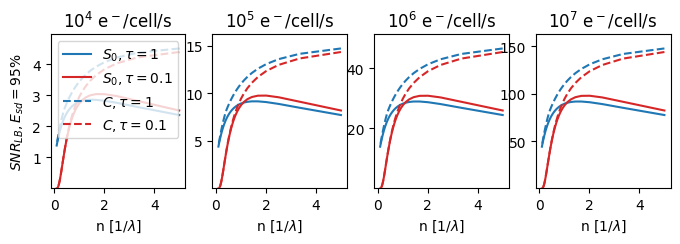

In [ ]:
#Figure 3 (a-d)

RD=1.2 #[e/p]
DN=1.03 #[e/p/s]
S=10e-2
px=100
lam=1
RD=RD*px
DN=DN*px

plt.figure(figsize=[8,2])

for jj in [4,5,6,7]:
  plt.subplot(1,4,jj-3)

  SN=10**jj
  data1=np.zeros(100)
  data2=np.zeros(100)
  data3=np.zeros(100)
  data4=np.zeros(100)
  da=np.linspace(0.2,10,100)
  for i in range(len(da)):
    d=da[i]

    E_=0.05

    tau=1
    x,y=pS(d,tau,lam)
    N=np.interp(E_,CDF(x,y),x);
    data1[i]=N*S*SN/(np.sqrt(NV(1/d,lam,RD,SN,DN)*2))

    tau=0.1
    x,y=pS(d,tau,lam)
    N=np.interp(E_,CDF(x,y),x);
    data2[i]=N*S*SN/(np.sqrt(NV(1/d,lam,RD,SN,DN)*2))

    tau=1
    x,y,dy=pC(d,tau,lam)
    N=np.interp(E_,CDF(x,y),x)/np.sqrt(EC(d,tau,lam));
    data3[i]=N*S*SN/(np.sqrt(NV(1/d,lam,RD,SN,DN)*2))

    tau=0.1
    x,y,dy=pC(d,tau,lam)
    N=np.interp(E_,CDF(x,y),x)/np.sqrt(EC(d,tau,lam));
    data4[i]=N*S*SN/(np.sqrt(NV(1/d,lam,RD,SN,DN)*2))

  plt.plot(1/da,data1,color='tab:blue')
  plt.plot(1/da,data2,color='tab:red')
  plt.plot(1/da,data3,'--',color='tab:blue')
  plt.plot(1/da,data4,'--',color='tab:red')

  plt.ylim(min(list(data1)+list(data2))*0.9,max(list(data3)+list(data4))*1.1)
  plt.title(r'$10^'+str(int(np.log10(SN)))+'$ e$^-$/cell/s')
  plt.xlabel(r'n [1/$\lambda$]')
  if jj==4:
    plt.ylabel(r'$SNR_{LB}, E_{sd}=95\%$')
    plt.legend([r'$S_0, \tau=1$',r'$S_0, \tau=0.1$',r'$C, \tau=1$',r'$C, \tau=0.1$'])

plt.savefig('Fig3_VoltageSampling_95.svg')

In [ ]:
#precalculate data for Figure 1 (l-o)

import pickle
px=100
SN=1e5 #[e/p/s]
n,n2,y,yp,y2,yp2=PLOTC(SN,px)

my_list = [n,n2,y,yp,y2,yp2]
file_name = "SN_"+str(SN)+".pkl"

with open(file_name, 'wb') as file: # 'wb' for write binary
    pickle.dump(my_list, file)

100%|██████████| 10/10 [12:09<00:00, 72.93s/it]


In [ ]:
#load saved data for Figure 1 (l-o)
[n,n2,y,yp,y2,yp2]=LoadData("SN_"+str(SN)+".pkl")

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1916216831.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [1/$\lambda$]')
/tmp/ipython-input-1916216831.py:33: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [1/$\lambda$]')
/tmp/ipython-input-1916216831.py:48: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [1/$\lambda$]')
/tmp/ipython-input-1916216831.py:63: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [1/$\lambda$]')


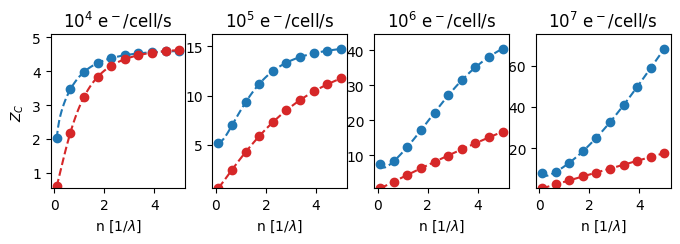

In [ ]:
#Figure 1 (l-o)

plt.figure(figsize=[8,2])
suffix='_V3.pkl';
SN=1e2
sb=int(np.log10(SN))
[n,n2,y,yp,y2,yp2]=LoadData("SN_"+str(SN)+suffix)

plt.subplot(1,4,1)

plt.plot(n2,y,'--',color='tab:blue')
plt.plot(n,yp,'o',color='tab:blue')

plt.plot(n2,y2,'--',color='tab:red')
plt.plot(n,yp2,'o',color='tab:red')
plt.ylim(min(list(y)+list(y2))*0.9,max(list(y)+list(y2))*1.1)

plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel('n [1/$\lambda$]')
plt.ylabel('$Z_C$')

SN=1e3
sb=int(np.log10(SN))
[n,n2,y,yp,y2,yp2]=LoadData("SN_"+str(SN)+suffix)
plt.subplot(1,4,2)

plt.plot(n2,y,'--',color='tab:blue')
plt.plot(n,yp,'o',color='tab:blue')

plt.plot(n2,y2,'--',color='tab:red')
plt.plot(n,yp2,'o',color='tab:red')
plt.ylim(min(list(y)+list(y2))*0.9,max(list(y)+list(y2))*1.1)

plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel('n [1/$\lambda$]')

SN=1e4
sb=int(np.log10(SN))
[n,n2,y,yp,y2,yp2]=LoadData("SN_"+str(SN)+suffix)
plt.subplot(1,4,3)

plt.plot(n2,y,'--',color='tab:blue')
plt.plot(n,yp,'o',color='tab:blue')

plt.plot(n2,y2,'--',color='tab:red')
plt.plot(n,yp2,'o',color='tab:red')
plt.ylim(min(list(y)+list(y2))*0.9,max(list(y)+list(y2))*1.1)

plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel('n [1/$\lambda$]')

SN=1e5
sb=int(np.log10(SN))
[n,n2,y,yp,y2,yp2]=LoadData("SN_"+str(SN)+suffix)
plt.subplot(1,4,4)

plt.plot(n2,y,'--',color='tab:blue')
plt.plot(n,yp,'o',color='tab:blue')

plt.plot(n2,y2,'--',color='tab:red')
plt.plot(n,yp2,'o',color='tab:red')
plt.ylim(min(list(y)+list(y2))*0.9,max(list(y)+list(y2))*1.1)

plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel('n [1/$\lambda$]')

plt.savefig('Fig2_ZC_V3.svg')

  0%|          | 0/10 [00:17<?, ?it/s]


KeyboardInterrupt: 

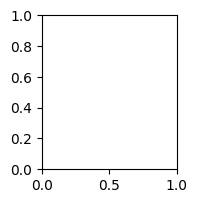

In [6]:
#Figure 1 (h-k)
plt.figure(figsize=[8,2])
SN=1e2 #[e/p/s]
plt.subplot(1,4,1)
PLOT(SN,px)
plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel(r'n [1/$\lambda$]')
plt.ylabel('$Z_P$')

SN=1e3 #[e/p/s]
plt.subplot(1,4,2)
PLOT(SN,px)
plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel(r'n [1/$\lambda$]')

SN=1e4 #[e/p/s]
plt.subplot(1,4,3)
PLOT(SN,px)
plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel(r'n [1/$\lambda$]')

SN=1e5 #[e/p/s]
plt.subplot(1,4,4)
PLOT(SN,px)
plt.title('$10^'+str(int(np.log10(SN*100)))+'$ e$^-$/cell/s')
plt.xlabel(r'n [1/$\lambda$]')
plt.savefig('Fig2_SP_V3.svg')

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-177/1469775834.py:25: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('x [1/$\lambda$]')


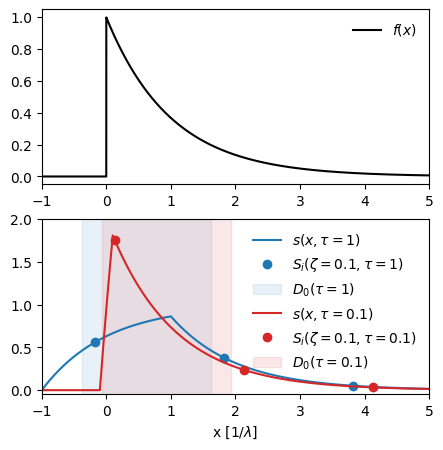

In [ ]:
#Figure 1 (b-c)
plt.figure(figsize=[5,5])
tau=1
lam=1
d=2

x=np.linspace(-2,6,10000)
xi=np.arange(-1,6)*d+CA(d,tau,lam)+d*0.1


plt.subplot(2,1,1)
plt.plot(x,Exp(x),'k')
plt.legend(['$f(x)$'],frameon=False)
plt.xlim(-1,5)

plt.subplot(2,1,2)
plt.plot(x,s(x,lam,tau,d))
plt.plot(xi,s(xi,lam,tau,d),'o',color='tab:blue')
plt.fill_between([CA(d,tau,lam),CA(d,tau,lam)+d],[-1,-1],[d,d],color='tab:blue',alpha=0.1)
tau=0.1
plt.plot(x,s(x,lam,tau,d),color='tab:red')
xi=np.arange(-1,6)*d+CA(d,tau,lam)+d*0.1
plt.plot(xi,s(xi,lam,tau,d),'o',color='tab:red')
plt.fill_between([CA(d,tau,lam),CA(d,tau,lam)+d],[-1,-1],[d,d],color='tab:red',alpha=0.1)
plt.legend([r'$s(x,\tau=1)$',r'$S_i(\zeta=0.1,\tau=1)$',r'$D_0(\tau=1)$',r'$s(x,\tau=0.1)$',r'$S_i(\zeta=0.1,\tau=0.1)$',r'$D_0(\tau=0.1)$'],frameon=False)
plt.xlabel('x [1/$\lambda$]')
plt.ylim(-0.05,d)
plt.xlim(-1,5)
plt.savefig('Fig1a.svg')

In [ ]:
lm=np.zeros([41,10000])
lm2=np.zeros([41,10000])
f=0.4e3
t=1e-3
for lap in trange(10000):
  tau=1
  eta=np.random.rand()
  n=f*t
  l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-1,40)])
  l=AdjustRefFrame(l)
  dl=l[1,0]-l[0,0]
  lm[:,lap]=l[:,1]
  #plt.subplot(1,2,1)
  #plt.plot(l[:,0],l[:,1],'tab:blue',alpha=0.3)

  tau=0.1
  eta=np.random.rand()
  l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-1,40)])
  l=AdjustRefFrame(l)
  dl=l[1,0]-l[0,0]
  #plt.subplot(1,2,2)
  lm2[:,lap]=l[:,1]
  #plt.plot(l[:,0],l[:,1],'tab:red',alpha=0.3)

In [ ]:
n=np.linspace(0.1,5,10)
n2=np.linspace(0.1,5,2000)
tau=1
ev=GetLM2(n,tau)
tau=0.1
ev2=GetLM2(n,tau)

NameError: name 'np' is not defined

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-177/2369571668.py:14: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [$\lambda$]')
/tmp/ipython-input-177/2369571668.py:30: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [$\lambda$]')


NameError: name 'n2' is not defined

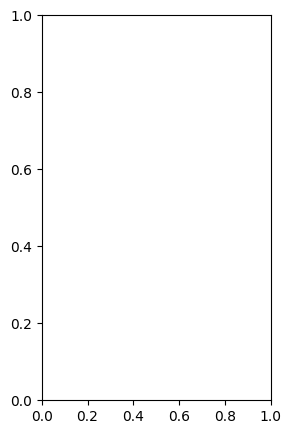

In [ ]:
#Figure 1 (e-f)
lam=1
tau=1
plt.figure(figsize=[6.5,5])

plt.subplot(1,2,1)
e=[E2(d,tau,0,lam) for d in 1/n2]
plt.plot(n2,e,'--',color='tab:blue')
v=np.array([V(d,tau,0,lam) for d in 1/n2])
plt.fill_between(n2,e-np.sqrt(v),e+np.sqrt(v),color='tab:blue',alpha=0.3)

plt.plot(n,ev[:,0],'o')
plt.errorbar(n,ev[:,0],np.sqrt(ev[:,1]),color='tab:blue', ls='none')
plt.legend(['$E[S_0]$ - theory','$SD[S_0]$ - theory','$E[S_0]$ - MC','$SD[S_0]$ - MC'],frameon=False)
plt.xlabel('n [$\lambda$]')
plt.ylabel('$S_0$')
plt.ylim(-0.7,2.7)

plt.subplot(1,2,2)
tau=0.1

e=[E2(d,tau,0,lam) for d in 1/n2]
v=np.array([V(d,tau,0,lam) for d in 1/n2])
plt.plot(n2,e,'--',color='tab:red')
plt.fill_between(n2,e-np.sqrt(v),e+np.sqrt(v),color='tab:red',alpha=0.3)

plt.plot(n,ev2[:,0],'o',color='tab:red')
plt.errorbar(n,ev2[:,0],np.sqrt(ev2[:,1]),color='tab:red', ls='none')

plt.legend(['$E[S_0]$ - theory','$SD[S_0]$ - theory','$E[S_0]$ - MC','$SD[S_0]$ - MC'],frameon=False)
plt.xlabel('n [$\lambda$]')
plt.ylim(-0.7,2.7)

plt.savefig('Fig1c.svg')

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3859395852.py:22: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('n [$\lambda$]')


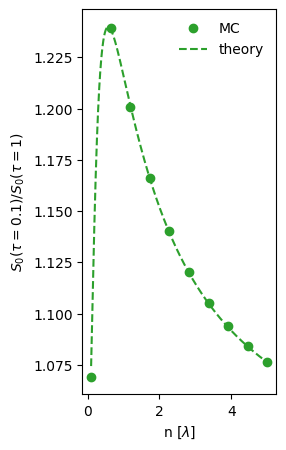

In [ ]:
#Figure 1 (g)
n=np.linspace(0.1,5,10)
n2=np.linspace(0.1,5,2000)
lam=1
tau=1
plt.figure(figsize=[2.5,5])
plt.plot(n,ev2[:,0]/ev[:,0],'o', color='tab:green')
e=np.array([E2(d,tau,0,lam) for d in 1/n2])
v=np.array([V(d,tau,0,lam) for d in 1/n2])
tau=0.1
e2=np.array([E2(d,tau,0,lam) for d in 1/n2])
v2=np.array([V(d,tau,0,lam) for d in 1/n2])


plt.plot(n2,e2/e,'--', color='tab:green')

v0=np.sqrt(1/e**2*v2+e2**2/e**4*v)

plt.xlabel('n [$\lambda$]')
plt.ylabel(r'$S_0(\tau=0.1)/S_0(\tau=1)$')
plt.legend(['MC','theory'],frameon=False)
plt.savefig('Fig1d.svg')

In [ ]:
#Data for Figure 1 (d-e)
lm=np.zeros([41,10000])
lm2=np.zeros([41,10000])
f=0.4e3
t=1e-3
for lap in trange(10000):
  tau=1
  eta=np.random.rand()
  n=f*t
  l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-20,21)])
  l=AdjustRefFrame(l)
  dl=l[1,0]-l[0,0]
  lm[:,lap]=l[:,1]

  tau=0.1
  eta=np.random.rand()
  l=np.array([Si_MC(i,n,tau,eta,Exp) for i in np.arange(-20,21)])
  l=AdjustRefFrame(l)
  dl=l[1,0]-l[0,0]
  lm2[:,lap]=l[:,1]

100%|██████████| 10000/10000 [01:15<00:00, 131.84it/s]


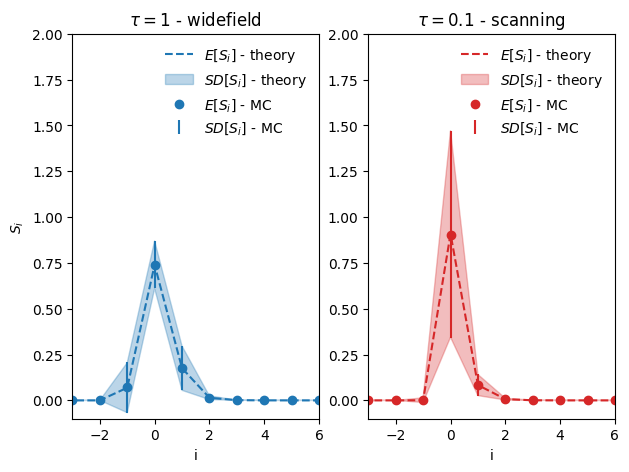

In [ ]:
#Figure 1 (d-e)
plt.figure(figsize=[7,5])
tau=1
lam=1
d=1/n

plt.subplot(1,2,1)
e=[E2(d,tau,i,lam) for i in np.arange(-20,21)]
plt.plot(l[:,0],e,'--',color='tab:blue')
v=np.array([V(d,tau,i,lam) for i in np.arange(-20,21)])
plt.fill_between(l[:,0],e-np.sqrt(v),e+np.sqrt(v),color='tab:blue',alpha=0.3)
plt.plot(l[:,0],np.mean(lm,1),'o',color='tab:blue')
plt.errorbar(l[:,0],np.mean(lm,1),np.std(lm,1),color='tab:blue', ls='none')

plt.xlim(-3,6)
plt.ylim(-0.1,2)
plt.xlabel('i')
plt.ylabel('$S_i$')
plt.legend(['$E[S_i]$ - theory','$SD[S_i]$ - theory','$E[S_i]$ - MC','$SD[S_i]$ - MC'],frameon=False)
plt.title(r'$\tau=1$ - widefield')

tau=0.1
plt.subplot(1,2,2)

e=[E2(d,tau,i,lam) for i in np.arange(-20,21)]
plt.plot(l[:,0],e,'--',color='tab:red')
v=np.array([V(d,tau,i,lam) for i in np.arange(-20,21)])
plt.fill_between(l[:,0],e-np.sqrt(v),e+np.sqrt(v),color='tab:red',alpha=0.3)
plt.plot(l[:,0],np.mean(lm2,1),'o',color='tab:red')
plt.errorbar(l[:,0],np.mean(lm2,1),np.std(lm2,1),color='tab:red', ls='none')

plt.xlim(-3,6)
plt.ylim(-0.1,2)
plt.xlabel('i')
plt.legend(['$E[S_i]$ - theory','$SD[S_i]$ - theory','$E[S_i]$ - MC','$SD[S_i]$ - MC'],frameon=False)
plt.title(r'$\tau=0.1$ - scanning')
plt.savefig('Fig1b.svg')

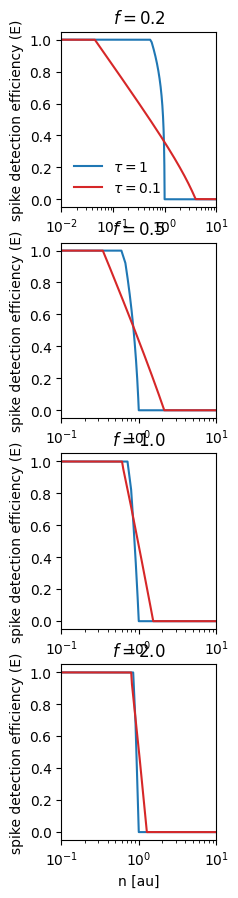

In [ ]:
#Figure 2 (f-i)
plt.figure(figsize=[2,10.5])

da=[5,2,1,0.5]
for lap in range(4):
  plt.subplot(4,1,lap+1)
  lam=1

  d=da[lap]

  tau=1
  x,y,dy=pC(d,tau,lam)
  N=max(x)/np.sqrt(EC(d,tau,lam))
  plt.semilogx(np.insert(np.insert(x/N/np.sqrt(EC(d,tau,lam)),0,1e-3),len(x)+1,1e2),np.insert(np.insert(1-CDF(x,y),0,1),len(x)+1,0))


  tau=0.1

  x,y,dy=pC(d,tau,lam)
  plt.semilogx(np.insert(np.insert(x/N/np.sqrt(EC(d,tau,lam)),0,1e-3),len(x)+1,1e2),np.insert(np.insert(1-CDF(x,y),0,1),len(x)+1,0),'tab:red')
  xmax=np.max(x/N/np.sqrt(EC(d,tau,lam)))
  xmin=np.min(x/N/np.sqrt(EC(d,tau,lam)))
  plt.xticks(10**np.arange(np.floor(np.log10(xmin)),np.ceil(np.log10(xmax))+1))
  plt.xlim(10**np.floor(np.log10(xmin)),10**np.ceil(np.log10(xmax)))
  if lap==3:
    plt.xlabel('n [au]')
  if lap==0:
    plt.legend([r'$\tau=1$',r'$\tau=0.1$'],frameon=False)
  plt.title('$f=$'+str(1/d))
  plt.ylabel('spike detection efficiency (E)')
  plt.savefig('Fig2a_C.svg')

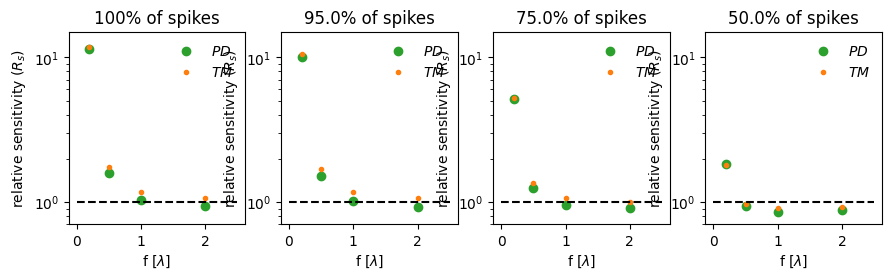

In [ ]:
#Figure 2 (j-m)
plt.figure(figsize=[10.5,2.5])
pA=[0,0.05,0.25,0.5]
for i in range(4):
  plt.subplot(1,4,i+1)
  p=pA[i];


  da=[5,2,1,0.5]
  for lap in range(4):
    lam=1

    d=da[lap]

    tau=1
    x,y=pS(d,tau,lam)
    N1=np.interp(p,CDF(x,y),x)


    tau=0.1
    x,y=pS(d,tau,lam)
    N2=np.interp(p,CDF(x,y),x)
    if lap==0:
      plt.semilogy(1/d,N1/N2,'o',color='tab:green',label=r'$PD$')
    else:
      plt.semilogy(1/d,N1/N2,'o',color='tab:green')

pA=[0,0.05,0.25,0.5]
for i in range(4):
  plt.subplot(1,4,i+1)
  p=pA[i];


  da=[5,2,1,0.5]
  for lap in range(4):
    lam=1

    d=da[lap]

    tau=1
    x,y,dy=pC(d,tau,lam)
    N1=np.interp(p,CDF(x,y),x)/np.sqrt(EC(d,tau,lam));


    tau=0.1
    x,y,dy=pC(d,tau,lam)
    N2=np.interp(p,CDF(x,y),x)/np.sqrt(EC(d,tau,lam));

    if lap==0:
      plt.semilogy(1/d,N1/N2,'.',color='tab:orange',label=r'$TM$')
    else:
      plt.semilogy(1/d,N1/N2,'.',color='tab:orange')
    plt.title(str(np.round(100-pA[i]*100,-0))+'% of spikes')
    plt.legend(frameon=False)
    plt.xlabel(r'f [$\lambda$]')
    plt.ylabel(r'relative sensitivity ($R_s$)')

  plt.plot([0,2.5],[1,1],'--k')
  plt.ylim(0.7,15)
plt.savefig('Fig2_D.svg')

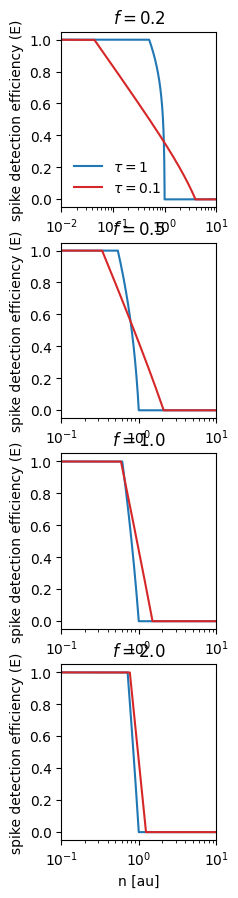

In [ ]:
#Figure 2 (b-e)
plt.figure(figsize=[2,10.5])

da=[5,2,1,0.5]
for lap in range(4):
  plt.subplot(4,1,lap+1)
  lam=1

  d=da[lap]

  tau=1
  x,y=pS(d,tau,lam)
  N=max(x)
  plt.semilogx(np.insert(np.insert(x/N,0,1e-3),len(x)+1,1e2),np.insert(np.insert(1-CDF(x,y),0,1),len(x)+1,0))


  tau=0.1
  x,y=pS(d,tau,lam)
  plt.semilogx(np.insert(np.insert(x/N,0,1e-3),len(x)+1,1e2),np.insert(np.insert(1-CDF(x,y),0,1),len(x)+1,0),'tab:red')
  xmax=np.max(x/N)
  xmin=np.min(x/N)
  plt.xticks(10**np.arange(np.floor(np.log10(xmin)),np.ceil(np.log10(xmax))+1))
  plt.xlim(10**np.floor(np.log10(xmin)),10**np.ceil(np.log10(xmax)))
  if lap==3:
    plt.xlabel('n [au]')
  if lap==0:
    plt.legend([r'$\tau=1$',r'$\tau=0.1$'],frameon=False)
  plt.title('$f=$'+str(1/d))
  plt.ylabel('spike detection efficiency (E)')
  plt.savefig('Fig2a_S0.svg')

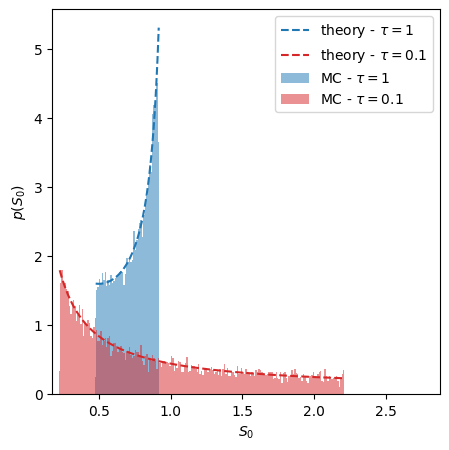

In [ ]:
#Figure 2 (a)
plt.figure(figsize=[5,5])

f=0.4
d=1/f
tau=1
lam=1
x0=CA(d,tau,lam)
dummy=plt.hist([s(np.array([x0+np.random.rand()*d]),lam,tau,d)[0] for lap in range(10000)],np.linspace(0,10,1000),density=True,color='tab:blue',alpha=0.5)

y,P=pS(d,tau,lam)
plt.plot(y,P,'--',color='tab:blue')

tau=0.1
x0=CA(d,tau,lam)
dummy=plt.hist([s(np.array([x0+np.random.rand()*d]),lam,tau,d)[0] for lap in range(10000)],np.linspace(0,10,1000),density=True,color='tab:red',alpha=0.5)

y,P=pS(d,tau,lam)
plt.plot(y,P,'--',color='tab:red')

plt.xlabel('$S_0$')
plt.ylabel('$p(S_0)$')
plt.legend([r'theory - $\tau=1$',r'theory - $\tau=0.1$',r'MC - $\tau=1$',r'MC - $\tau=0.1$'])
plt.xlim([np.min(y)/1.3,np.max(y)*1.3])
plt.savefig('Fig2b.svg')